<a href="https://colab.research.google.com/github/de-fernandez/CPE-313-CPE32S3/blob/main/Don%20Eleazar%20T.%20Fernandez%2C%20CPE32S3%2C%20CPE%20313%20(Hands-on%20Activity%204.2%20Transfer%20Learning%20on%20PyTorch).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transfer Learning using PyTorch

In [1]:
!nvidia-smi

Thu Feb 19 07:26:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   75C    P0             35W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Load Important Libraries

In [2]:
# License: BSD
# Author: Sasank Chilamkurthy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

cudnn.benchmark = True
plt.ion()   # interactive mode

## Load Data
=========

We will use torchvision and torch.utils.data packages for loading the
data.

The problem we\'re going to solve today is to train a model to classify
**ants** and **bees**. We have about 120 training images each for ants
and bees. There are 75 validation images for each class. Usually, this
is a very small dataset to generalize upon, if trained from scratch.
Since we are using transfer learning, we should be able to generalize
reasonably well.

This dataset is a very small subset of imagenet.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!rm -R /content/drive/MyDrive/CPE313/hymenoptera_data/train/.ipynb_checkpoints
!ls /content/drive/MyDrive/CPE313/hymenoptera_data/train -a   #to make sure that the deletion has occurred

!rm -R /content/drive/MyDrive/CPE313/hymenoptera_data/val/.ipynb_checkpoints
!ls /content/drive/MyDrive/CPE313/hymenoptera_data/val -a   #to make sure that the deletion has occurred

rm: cannot remove '/content/drive/MyDrive/CPE313/hymenoptera_data/train/.ipynb_checkpoints': No such file or directory
ants  bees
rm: cannot remove '/content/drive/MyDrive/CPE313/hymenoptera_data/val/.ipynb_checkpoints': No such file or directory
ants  bees


In [53]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = '/content/drive/MyDrive/CPE313/hymenoptera_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

# We want to be able to train our model on an `accelerator <https://pytorch.org/docs/stable/torch.html#accelerators>`__
# such as CUDA, MPS, MTIA, or XPU. If the current accelerator is available, we will use it. Otherwise, we use the CPU.

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


## Visualize a few images
======================

Let\'s visualize a few training images so as to understand the data
augmentations.


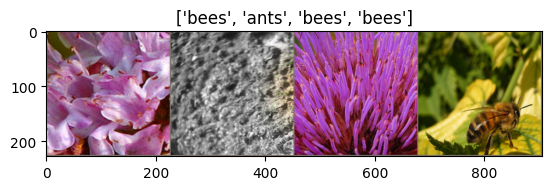

In [54]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

## Training the model
==================

Now, let\'s write a general function to train a model. Here, we will
illustrate:

-   Scheduling the learning rate
-   Saving the best model

In the following, parameter `scheduler` is an LR scheduler object from
`torch.optim.lr_scheduler`.


In [55]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

## Visualizing the model predictions
=================================

Generic function to display predictions for a few images


In [56]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

## Finetuning the ConvNet
======================

Load a pretrained model and reset final fully connected layer.


In [59]:
model_ft = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to ``nn.Linear(num_ftrs, len(class_names))``.
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

## Train and evaluate
==================

It should take around 15-25 min on CPU. On GPU though, it takes less
than a minute.


In [60]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

Epoch 0/24
----------
train Loss: 0.7390 Acc: 0.6639
val Loss: 0.2020 Acc: 0.9281

Epoch 1/24
----------
train Loss: 0.7426 Acc: 0.7418
val Loss: 0.2711 Acc: 0.9020

Epoch 2/24
----------
train Loss: 0.4764 Acc: 0.8115
val Loss: 0.2555 Acc: 0.8889

Epoch 3/24
----------
train Loss: 0.4701 Acc: 0.8238
val Loss: 0.3368 Acc: 0.8758

Epoch 4/24
----------
train Loss: 0.5590 Acc: 0.7951
val Loss: 0.2226 Acc: 0.9216

Epoch 5/24
----------
train Loss: 0.5742 Acc: 0.7746
val Loss: 0.6521 Acc: 0.8235

Epoch 6/24
----------
train Loss: 0.4608 Acc: 0.8443
val Loss: 0.2871 Acc: 0.9150

Epoch 7/24
----------
train Loss: 0.4977 Acc: 0.7992
val Loss: 0.2137 Acc: 0.9346

Epoch 8/24
----------
train Loss: 0.3881 Acc: 0.8566
val Loss: 0.2030 Acc: 0.9281

Epoch 9/24
----------
train Loss: 0.2956 Acc: 0.8811
val Loss: 0.1960 Acc: 0.9412

Epoch 10/24
----------
train Loss: 0.2321 Acc: 0.8934
val Loss: 0.1885 Acc: 0.9542

Epoch 11/24
----------
train Loss: 0.2486 Acc: 0.8934
val Loss: 0.1811 Acc: 0.9346

Ep

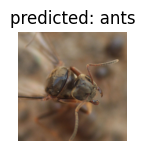

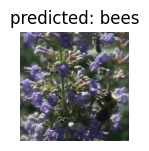

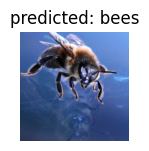

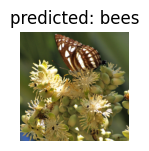

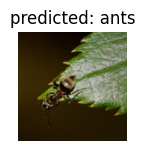

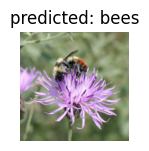

In [11]:
visualize_model(model_ft)

## ConvNet as fixed feature extractor
==================================

Here, we need to freeze all the network except the final layer. We need
to set `requires_grad = False` to freeze the parameters so that the
gradients are not computed in `backward()`.

You can read more about this in the documentation
[here](https://pytorch.org/docs/notes/autograd.html#excluding-subgraphs-from-backward).


In [66]:
model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for param in model_conv.parameters():
    param.requires_grad = False

# Parameters of newly constructed modules have requires_grad=True by default
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opposed to before.
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

## Train and evaluate
==================

On CPU this will take about half the time compared to previous scenario.
This is expected as gradients don\'t need to be computed for most of the
network. However, forward does need to be computed.


In [68]:
model_conv = train_model(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.5546 Acc: 0.7377
val Loss: 0.1969 Acc: 0.9412

Epoch 1/24
----------
train Loss: 0.4592 Acc: 0.8074
val Loss: 0.1901 Acc: 0.9346

Epoch 2/24
----------
train Loss: 0.5486 Acc: 0.7787
val Loss: 0.3949 Acc: 0.8301

Epoch 3/24
----------
train Loss: 0.5670 Acc: 0.7869
val Loss: 0.1962 Acc: 0.9281

Epoch 4/24
----------
train Loss: 0.4896 Acc: 0.7828
val Loss: 0.1942 Acc: 0.9477

Epoch 5/24
----------
train Loss: 0.4020 Acc: 0.8525
val Loss: 0.2582 Acc: 0.8954

Epoch 6/24
----------
train Loss: 0.3822 Acc: 0.8320
val Loss: 0.1724 Acc: 0.9412

Epoch 7/24
----------
train Loss: 0.2979 Acc: 0.8648
val Loss: 0.1804 Acc: 0.9412

Epoch 8/24
----------
train Loss: 0.3582 Acc: 0.8484
val Loss: 0.1834 Acc: 0.9412

Epoch 9/24
----------
train Loss: 0.3562 Acc: 0.8566
val Loss: 0.1683 Acc: 0.9542

Epoch 10/24
----------
train Loss: 0.3702 Acc: 0.8197
val Loss: 0.1858 Acc: 0.9477

Epoch 11/24
----------
train Loss: 0.3276 Acc: 0.8689
val Loss: 0.1762 Acc: 0.9477

Ep

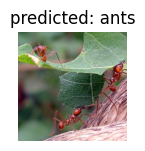

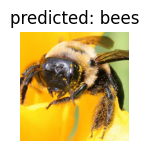

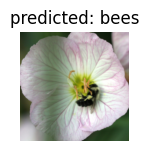

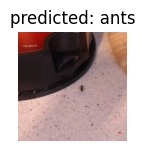

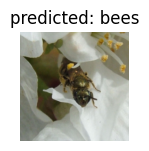

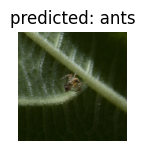

In [14]:
visualize_model(model_conv)

plt.ioff()
plt.show()

## Inference on custom images
==========================

Use the trained model to make predictions on custom images and visualize
the predicted class labels along with the images.


In [15]:
def visualize_model_predictions(model,img_path):
    was_training = model.training
    model.eval()

    img = Image.open(img_path)
    img = data_transforms['val'](img)
    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, 1)

        ax = plt.subplot(2,2,1)
        ax.axis('off')
        ax.set_title(f'Predicted: {class_names[preds[0]]}')
        imshow(img.cpu().data[0])

        model.train(mode=was_training)

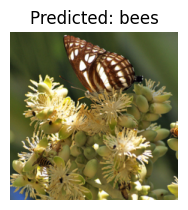

In [16]:
visualize_model_predictions(
    model_conv,
    img_path='/content/drive/MyDrive/CPE313/hymenoptera_data/val/bees/72100438_73de9f17af.jpg'
)

plt.ioff()
plt.show()

## Further Learning
================

If you would like to learn more about the applications of transfer
learning, checkout the
* [Quantized Transfer Learning for Computer Vision
Tutorial](https://pytorch.org/tutorials/intermediate/quantized_transfer_learning_tutorial.html).


# Supplementary Activity

In a new notebook, perform the following:
1. Choose a pretrained model.
2. Finetune on your dataset from the previous activity.
3. Evaluate the performance of the previous model to this finetuned model.

4. Utilize the pretrained ConvNet model as fixed feature extractor.
5. Evaluate the performance of the previous model to this finetuned model.

6.  Discuss the following:
  * How did finetuning affect your performance?
  * Which of the different situations for rule of thumb were applicable to you?

1. Choose a pretrained model.

In [47]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.optim import lr_scheduler
from tempfile import TemporaryDirectory

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = '/content/drive/MyDrive/CPE313/hymenoptera_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


2. Finetune on your dataset from the previous activity.

In [29]:
model = models.googlenet(pretrained=True)

num_classes = 2

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)

if model.aux_logits:
    num_ftrs_aux = model.AuxLogits.fc.in_features
    model.AuxLogits.fc = nn.Linear(num_ftrs_aux, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_ft = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [36]:
def train_model_googlenet(model, dataloaders, dataset_sizes, device, criterion, optimizer, scheduler=None, num_epochs=25):
    since = time.time()

    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_googlenet_params.pt')
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()
                else:
                    model.eval()

                running_loss = 0.0
                running_corrects = 0

                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    optimizer.zero_grad()

                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)

                        # Handle GoogLeNet outputs with optional auxiliary logits
                        if model.aux_logits and phase == 'train':
                            # outputs is a tuple: (main_logits, aux_logits)
                            main_logits, aux_logits = outputs
                            loss_main = criterion(main_logits, labels)
                            loss_aux = criterion(aux_logits, labels)
                            loss = loss_main + 0.4 * loss_aux
                            logits = main_logits
                        else:
                            # aux_logits disabled or in eval
                            logits = outputs
                            loss = criterion(logits, labels)

                        _, preds = torch.max(logits, 1)

                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)

                if phase == 'train' and scheduler is not None:
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # Save best weights
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:.4f}')

        # Load best weights
        model.load_state_dict(torch.load(best_model_params_path))

    return model

3. Evaluate the performance of the previous model to this finetuned model.

In [39]:
model = train_model_googlenet(
    model=model,
    dataloaders=dataloaders,
    dataset_sizes=dataset_sizes,
    device=device,
    criterion=criterion,
    optimizer=optimizer_ft,
    scheduler=exp_lr_scheduler,
    num_epochs=25
)


Epoch 0/24
----------


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


train Loss: 0.5983 Acc: 0.6721
val Loss: 0.4301 Acc: 0.8039

Epoch 1/24
----------
train Loss: 0.5480 Acc: 0.7254
val Loss: 0.2856 Acc: 0.8889

Epoch 2/24
----------
train Loss: 0.5503 Acc: 0.7172
val Loss: 0.2842 Acc: 0.9150

Epoch 3/24
----------
train Loss: 0.3441 Acc: 0.8525
val Loss: 0.2024 Acc: 0.9346

Epoch 4/24
----------
train Loss: 0.3695 Acc: 0.8279
val Loss: 0.2166 Acc: 0.9150

Epoch 5/24
----------
train Loss: 0.3557 Acc: 0.8320
val Loss: 0.2367 Acc: 0.9085

Epoch 6/24
----------
train Loss: 0.3179 Acc: 0.8770
val Loss: 0.2029 Acc: 0.9346

Epoch 7/24
----------
train Loss: 0.3149 Acc: 0.8525
val Loss: 0.1793 Acc: 0.9412

Epoch 8/24
----------
train Loss: 0.2750 Acc: 0.9057
val Loss: 0.2051 Acc: 0.9412

Epoch 9/24
----------
train Loss: 0.2055 Acc: 0.9221
val Loss: 0.1760 Acc: 0.9346

Epoch 10/24
----------
train Loss: 0.2803 Acc: 0.8811
val Loss: 0.1796 Acc: 0.9346

Epoch 11/24
----------
train Loss: 0.2837 Acc: 0.8689
val Loss: 0.2127 Acc: 0.9216

Epoch 12/24
----------
t

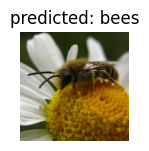

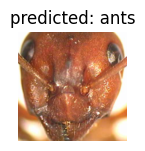

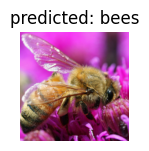

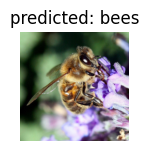

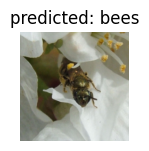

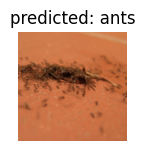

In [45]:
visualize_model(model)

plt.ioff()
plt.show()

4. Utilize the pretrained ConvNet model as fixed feature extractor.

In [61]:
model_conv2 = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for param in model_conv2.parameters():
    param.requires_grad = False

# Parameters of newly constructed modules have requires_grad=True by default
num_ftrs = model_conv2.fc.in_features
model_conv2.fc = nn.Linear(num_ftrs, 2)

model_conv2 = model_conv2.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opposed to before.
optimizer_conv = optim.SGD(model_conv2.fc.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

In [69]:
model_conv2 = train_model(model_conv2, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

Epoch 0/24
----------
train Loss: 0.3772 Acc: 0.8238
val Loss: 0.1808 Acc: 0.9477

Epoch 1/24
----------
train Loss: 0.3859 Acc: 0.8156
val Loss: 0.1707 Acc: 0.9477

Epoch 2/24
----------
train Loss: 0.3730 Acc: 0.8320
val Loss: 0.1774 Acc: 0.9542

Epoch 3/24
----------
train Loss: 0.2283 Acc: 0.8852
val Loss: 0.1741 Acc: 0.9477

Epoch 4/24
----------
train Loss: 0.2400 Acc: 0.8811
val Loss: 0.1801 Acc: 0.9542

Epoch 5/24
----------
train Loss: 0.4261 Acc: 0.8074
val Loss: 0.1616 Acc: 0.9542

Epoch 6/24
----------
train Loss: 0.2502 Acc: 0.8934
val Loss: 0.1667 Acc: 0.9542

Epoch 7/24
----------
train Loss: 0.3856 Acc: 0.8484
val Loss: 0.1736 Acc: 0.9412

Epoch 8/24
----------
train Loss: 0.3425 Acc: 0.8525
val Loss: 0.1844 Acc: 0.9542

Epoch 9/24
----------
train Loss: 0.3745 Acc: 0.8361
val Loss: 0.1705 Acc: 0.9542

Epoch 10/24
----------
train Loss: 0.3319 Acc: 0.8361
val Loss: 0.1894 Acc: 0.9412

Epoch 11/24
----------
train Loss: 0.3818 Acc: 0.8402
val Loss: 0.1791 Acc: 0.9542

Ep

5. Evaluate the performance of the previous model to this finetuned model.

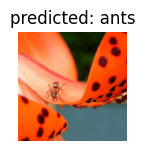

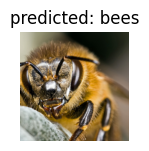

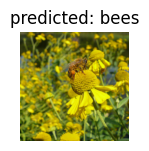

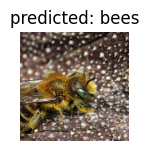

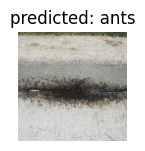

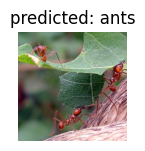

In [70]:
visualize_model(model_conv2)

plt.ioff()
plt.show()

Discuss the following:

How did finetuning affect your performance?
The finetuning improved the model performance because the model adjusted its learned features to match the dataset. It resulted in slightly higher accuracy compared to using the pretrained model without training.

Which of the different situations for rule of thumb were applicable to you?
Using finetuning because the dataset can be different from the original dataset used to train the pretrained model.


## Conclusion

In this activity, we learned how transfer learning works by using a pre trained model instead of building one from scratch. The finetuning helped the model learn better from our dataset and improved its accuracy, while using the model as a fixed feature extractor was faster but less accurate. Overall, the activity showed that transfer learning is a good and faster way to build deep learning models with less training time.
